In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.random as rnd

# initial structure follows from https://github.com/stmorse/hawkes

class Hawkes:
    def __init__(self, μ = [0.1], α = [[0.5]], β=[[1.0]]):
        self.μ = np.array(μ, dtype=float)
        self.α = np.array(α, dtype=float)
        self.β = np.array(β, dtype=float)
        self.mark_dim = self.μ.shape[0]
        
        if self.α.shape != (self.mark_dim, self.mark_dim):
            raise ValueError("α must be an M x M matrix, where M is the number of mark types.")
        
        if self.β.shape != (self.mark_dim, self.mark_dim):
            raise ValueError("β must be an M x M matrix, where M is the number of mark types.")
        
        if np.any(self.μ < 0):
            raise print("All entries of μ must be nonnegative.")
        
        if np.any(self.α < 0):
            raise print("All entries of α must be nonnegative.")
        
        if np.any(self.β <= 0):
            raise print("All entries of β must be strictly positive.")
        
        abs_max_eig = np.max(np.abs(np.linalg.eigvals(self.α/self.β))) 
        print(f'Modulus of max eigenvalue: {abs_max_eig:1.5f}')
        if abs_max_eig >= 1:
            print('(WARNING) Unstable.')
        else:
            print('Appears stable')
        
        
    def check_stability(self):
        abs_max_eig = np.max(np.abs(np.linalg.eigvals(self.α/self.β))) 
        print(f'Modulus of max eigenvalue: {abs_max_eig:1.5f}')
        if abs_max_eig >= 1:
            print('(WARNING) Unstable.')
        else:
            print('Appears stable')
            
    def get_λ(self, data, t, m):
        """Compute the left-limit intensity at t"""
        if len(data) == 0:
            return self.μ[m]
        seq = np.array(data) # note that this converts the integer-valued marks in the 2nd column to floats
        seq = seq[seq[:,0] < t]
        return self.μ[m] + np.sum(np.fromiter((self.α[m,int(j)] * np.exp(-self.β[m,int(j)]*(t-t_k)) 
                                               for t_k, j in seq), dtype = float))
    
    def get_I_M(self, data, t):
        lambda_vec = np.array([self.get_λ(data, t, m) for m in range(self.mark_dim)])
        return np.cumsum(lambda_vec)
    
    def simulate(self, T, data = None):
        # data = np.empty((0, 2)) if data is None else np.array(data, dtype=float)
        data = [] if data is None else list(data)
        
        # initialization
        I_M = self.get_I_M(data, 0)
        max_intensity = I_M[-1]
        if max_intensity == 0:
            raise ValueError("Cannot generate any points if all base intensities equal 0.")
        
        # first event
        s = -1/max_intensity * np.log(rnd.uniform())
        if s > T:
            raise ValueError("T is too small for given parameters.")
        D = rnd.uniform()
        # m_i = np.argwhere(D <= I_M/max_intensity)[0][0]
        m_i = np.searchsorted(I_M/max_intensity, D)
        t_i = s
        # data = np.append(data, [[t_i, m_i]], axis = 0)
        data.append((t_i, m_i))
        
        
        # general routine
        while True:
            
            # update maximum intensity
            I_M = self.get_I_M(data, t_i) # update maximum intensity: I* <- I^M(t_{i-1}) + jump from last accepted mark
            max_intensity = I_M[-1] + np.sum(self.α[:, m_i])
            
            # this is the "current time" from which step 3.2.b proposes a new date
            s_current = t_i
            
            while True:
                # new event
                s = s_current - 1/max_intensity * np.log(rnd.uniform())
                if s > T:
                    return np.array(data)
                I_M = self.get_I_M(data, s)
                
                # Attribution-Rejection test
                D = rnd.uniform()
                if D <= I_M[-1]/max_intensity:
                    t_i = s
                    # m_i = np.argwhere(D <= I_M/max_intensity)[0][0]
                    m_i = np.searchsorted(I_M/max_intensity, D)
                    # data = np.append(data, [[t_i, m_i]], axis = 0)
                    data.append((t_i, m_i))
                    break
                else:
                    max_intensity = I_M[-1]
                    s_current = s        

In [147]:
# import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

def plot_events_and_rates(hawkes_object=None, data=None, horizon=None):

    horizon = np.amax(data[:,0]) if horizon is None else horizon
    dim = hawkes_object.mark_dim

    f, axarr = plt.subplots(
        dim*2, 1, 
        sharex='col', 
        gridspec_kw={'height_ratios':sum([[3,1] for i in range(dim)],[])}, 
        figsize=(8, dim*2)
    )

    xs = np.linspace(0, horizon, int(horizon*10))
    for i in range(dim):
        row = i * 2

        # plot rate
        r = [hawkes_object.get_λ(data, ct, i) for ct in xs]
        axarr[row].plot(xs, r)
        axarr[row].set_ylim([-0.01, np.amax(r)+(np.amax(r)/2.)])
        axarr[row].set_ylabel('$\lambda(t)_{%d}$' % i, fontsize=14)
        r = []

        # plot events
        subseq = data[data[:,1]==i][:,0]
        axarr[row+1].plot(subseq, np.zeros(len(subseq)) - 0.5, '^', alpha=0.2)
        axarr[row+1].yaxis.set_visible(False)
        axarr[row+1].set_xlim([0, horizon])

    plt.tight_layout()

Modulus of max eigenvalue: 0.37913
Appears stable


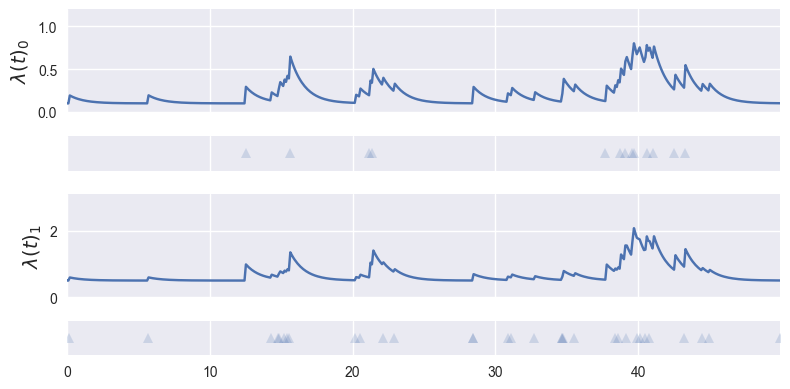

In [159]:
μ = np.array([.1, .5], dtype=float)
α = np.array([[.2, .1],
              [.5, .1]], dtype=float)
β = np.array([[1,1],
              [1,1]], dtype=float)

P2 = Hawkes(μ, α, β)
seq2 = P2.simulate(50)
plot_events_and_rates(hawkes_object=P2, data=seq2)



In [128]:
len([])

0

In [121]:
μ = np.array([.1, .5], dtype=float)
α = np.array([[.2, .1],
              [.5, .1]], dtype=float)
β = np.array([[1,1],
              [1,1]], dtype=float)
mark_dim = μ.shape[0]

def get_λ(data, t, m):
    """Compute the left-limit intensity at t"""
    seq = np.array(data)
    if not np.all(t > seq[:,0]):
        seq = seq[seq[:,0] < t]
    return μ[m] + np.sum([α[m,j] * np.exp(-β[m,j]*(t-t_k)) for t_k, j in seq])

def get_I_M(data, t):
    lambda_vec = np.array([get_λ(data, t, m) for m in range(mark_dim)])
    return np.cumsum(lambda_vec)

t_i = 1
m_i = 0

I_M_test = np.array([np.sum(μ[:i+1]) for i in range(mark_dim)])
# I_M_test1 = np.array([np.sum(get_λ(np.empty((0, 2)), 0, m) for m in range(M)) for M in range(1,mark_dim+1)])
# I_M_test2 = np.array([np.sum(get_λ(np.array([[1, 0]]), 1, m) for m in range(M)) for M in range(1,mark_dim+1)])
I_M_test1 = get_I_M(np.empty((0, 2)), 0)
I_M_test2 = get_I_M(np.array([[1, 0]]), 1)

print(I_M_test1)
print(I_M_test2)

[0.1 0.6]
[0.1 0.6]


In [120]:
print(I_M_test1)
print(I_M_test2)

[0.1 0.6]
[0.1 0.6]


In [ ]:
test1 = np.array([0,2])